# Cuaderno 04 · Los límites causales de la explicabilidad: del SHAP observacional al SHAP causal

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 4 de 10

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

Este capítulo desarrolla con detalle por qué una atribución de características *fiel al modelo* —como SHAP— **no** es, en general, una atribución *causal*, y qué se necesita para que lo sea. A diferencia de un recetario de librerías, aquí se construye la teoría: se define el valor de Shapley y se explica cada término de su fórmula; se distinguen dos **funciones de valor** (la condicional y la intervencional) introduciendo el operador $do$ de Pearl; y se demuestra, en el caso lineal-gaussiano —donde todo se calcula a mano—, **exactamente** dónde y por qué difieren. Recién entonces se llevan las ideas a un modelo entrenado sobre datos reales. La conclusión motiva la Sección 2 del curso: atribuir causalmente exige un modelo causal.

## Contenido y objetivos

1. **El valor de Shapley, en detalle** — juego cooperativo, fórmula explicada término a término, formulación por órdenes, ejemplo a mano y axiomas.
2. **La función de valor: dónde entra la causalidad** — valor condicional vs. intervencional, el operador $do$, y la **Proposición lineal-gaussiana** con su demostración y verificación numérica.
3. **Cuando los ausentes son descendientes** — modelos causales estructurales (SCM) y la atribución causal; demostración con verdad conocida.
4. **El efecto en un modelo real** — SHAP observacional vs. intervencional sobre German Credit.
5. **Causal SHAP, Shapley asimétrico y do-SHAP** — cómo se incorpora el grafo.

**Objetivos.** (i) Deducir la fórmula de Shapley y sus dos formulaciones; (ii) definir con precisión las funciones de valor condicional e intervencional y el operador $do$; (iii) **demostrar** la discrepancia en el caso lineal-gaussiano y verificarla numéricamente; (iv) generalizar al SCM y comprobarlo; (v) constatar el efecto en datos reales y justificar la necesidad del modelo causal.

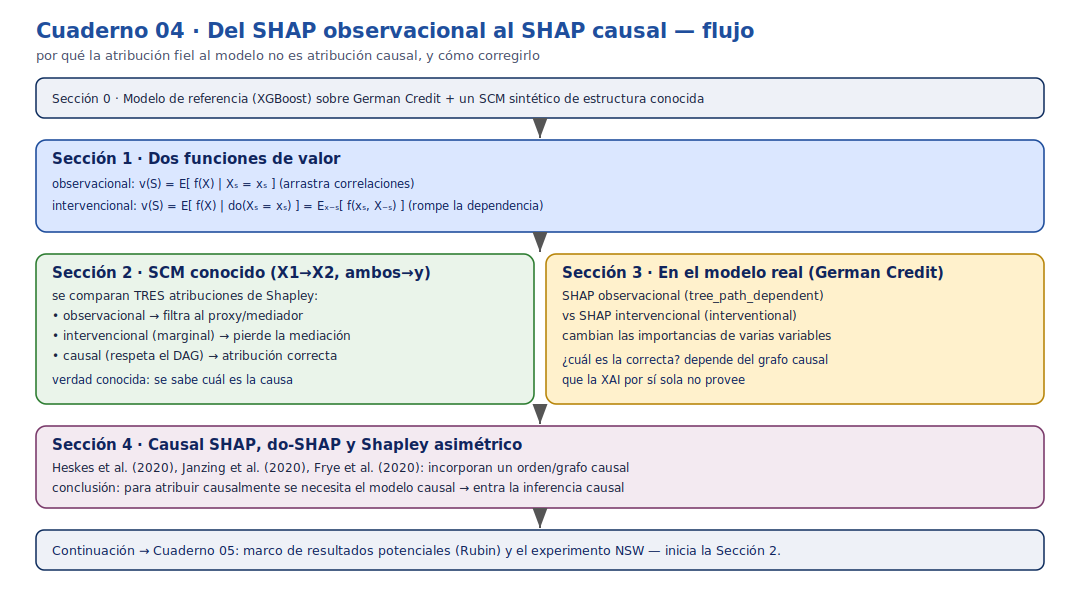

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/04_flujo.svg')
if not _svg.exists():
    _svg = Path('img/04_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y utilidades
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_german_credit

import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE); np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})
print("Entorno listo · semilla =", RANDOM_STATE)

Entorno listo · semilla = 42


## Sección 1 · El valor de Shapley, en detalle

Explicar una predicción $f(x)$ de forma **aditiva** es repartir su valor en una suma de aportes, uno por variable: $f(x)=\phi_0+\sum_{i=1}^M \phi_i$. El problema —¿cómo repartir *con justicia*?— es un problema clásico de teoría de juegos cooperativos, y tiene una **única** solución razonable: el valor de Shapley. Antes de usarlo conviene entenderlo.

> **Definición 1.1 (juego cooperativo).** Un *juego cooperativo* sobre un conjunto de $M$ jugadores $N=\{1,\dots,M\}$ es una función de valor
> $$ v:\; 2^{N}\longrightarrow \mathbb{R}, \qquad v(\varnothing)=0, $$
> que asigna a cada **coalición** $S\subseteq N$ el "beneficio" $v(S)$ que sus miembros obtienen al cooperar. En nuestro contexto, los jugadores son las **variables**, y $v(S)$ será "lo que el modelo predice cuando solo se conocen las variables de $S$" (precisaremos esto en la Sección 2).

La pregunta es cómo distribuir el beneficio total $v(N)$ entre los jugadores. La cantidad que mide cuánto *añade* el jugador $i$ a una coalición $S$ que no lo contiene es su **contribución marginal**:
$$ \Delta_i(S)\;=\;v(S\cup\{i\})-v(S). $$
La idea de Shapley: el aporte justo de $i$ es el **promedio** de su contribución marginal sobre todas las formas posibles de ir formando la gran coalición.

> **Definición 1.2 (valor de Shapley).** El *valor de Shapley* del jugador $i$ es
> $$ \boxed{\;\phi_i \;=\; \sum_{S\subseteq N\setminus\{i\}} \frac{|S|!\,\big(M-|S|-1\big)!}{M!}\;\big[\,v(S\cup\{i\})-v(S)\,\big]\;} $$

Leamos la fórmula **término a término**, porque cada factor tiene un significado preciso:

- La suma recorre **todas las coaliciones $S$ que no contienen a $i$**: son los posibles "grupos ya formados" a los que $i$ podría unirse.
- $\big[v(S\cup\{i\})-v(S)\big]=\Delta_i(S)$ es la **contribución marginal** de $i$ a ese grupo.
- El peso $\dfrac{|S|!\,(M-|S|-1)!}{M!}$ es una **probabilidad**: la de que, al formar la coalición total en un **orden al azar** (uno de los $M!$ órdenes equiprobables), los miembros de $S$ lleguen *exactamente antes* que $i$ y el resto *después*.

¿De dónde sale ese peso? Fijado $i$ y una coalición $S$ de tamaño $|S|=s$ que lo precede: hay $s!$ maneras de ordenar a los que llegan antes (los de $S$), luego entra $i$, y hay $(M-s-1)!$ maneras de ordenar a los $M-s-1$ restantes. Como hay $M!$ órdenes en total,
$$ \Pr[\text{los de } S \text{ preceden a } i] \;=\; \frac{s!\,(M-s-1)!}{M!}. $$
Por eso el valor de Shapley es, equivalentemente, un **promedio sobre órdenes**.

> **Formulación equivalente (por órdenes de llegada).** Sea $\Pi$ el conjunto de los $M!$ órdenes (permutaciones) de los jugadores y, para un orden $\pi$, sea $\mathrm{Pre}_i(\pi)$ el conjunto de jugadores que **preceden** a $i$ en $\pi$. Entonces
> $$ \phi_i \;=\; \frac{1}{M!}\sum_{\pi\in\Pi}\Big[\,v\big(\mathrm{Pre}_i(\pi)\cup\{i\}\big)-v\big(\mathrm{Pre}_i(\pi)\big)\,\Big]. $$
> Es decir: se hace entrar a los jugadores uno a uno en un orden, se anota cuánto añade $i$ al entrar, y se promedia sobre todos los órdenes. Esta forma es más intuitiva; la de la Definición 1.2 es la misma suma, agrupando los órdenes que comparten el mismo conjunto $S$ de predecesores.

> **Ejemplo 1.1 (cálculo explícito con dos jugadores).** Sea $M=2$ y escribamos $v(\varnothing)=0$, $v(\{1\})=a$, $v(\{2\})=b$, $v(\{1,2\})=c$. Hay $2!=2$ órdenes:
>
> | orden | aporte de 1 | aporte de 2 |
> |---|---|---|
> | $1\to2$ | $v(\{1\})-v(\varnothing)=a$ | $v(\{1,2\})-v(\{1\})=c-a$ |
> | $2\to1$ | $v(\{1,2\})-v(\{2\})=c-b$ | $v(\{2\})-v(\varnothing)=b$ |
>
> Promediando cada columna,
> $$ \phi_1=\tfrac12\big[a+(c-b)\big], \qquad \phi_2=\tfrac12\big[b+(c-a)\big]. $$
> **Intuición.** El aporte de $1$ es el promedio entre "lo que vale solo" ($a$) y "lo que añade cuando $2$ ya estaba" ($c-b$). Si hay sinergia ($c>a+b$), ambos comparten la sinergia por igual. Además se cumple la **eficiencia**: $\phi_1+\phi_2=c=v(\{1,2\})$. Verifiquémoslo numéricamente.

In [3]:
a, b, c = 0.40, 0.10, 0.80                 # valores de coalición de ejemplo
phi1 = 0.5 * (a + (c - b)); phi2 = 0.5 * (b + (c - a))
print(f"phi_1 = {phi1:.3f}   phi_2 = {phi2:.3f}")
print(f"suma  = {phi1 + phi2:.3f}   v(N) = c = {c:.3f}   (eficiencia: deben coincidir)")

phi_1 = 0.550   phi_2 = 0.250
suma  = 0.800   v(N) = c = 0.800   (eficiencia: deben coincidir)


> **Observación 1.1 (axiomas y unicidad).** El valor de Shapley es la **única** regla de reparto que satisface simultáneamente:
> - **Eficiencia:** $\sum_i \phi_i = v(N)-v(\varnothing)$ (se reparte todo el beneficio).
> - **Simetría:** si $v(S\cup\{i\})=v(S\cup\{j\})$ para toda $S$ sin $i,j$, entonces $\phi_i=\phi_j$ (jugadores intercambiables reciben lo mismo).
> - **Jugador nulo:** si $\Delta_i(S)=0$ para toda $S$, entonces $\phi_i=0$.
> - **Linealidad:** $\phi_i(v+w)=\phi_i(v)+\phi_i(w)$.
>
> (Shapley, 1953.) Esta unicidad es la razón por la que se prefiere a alternativas *ad hoc*. Todo lo anterior es **independiente** de qué sea $v$. La causalidad entra al *elegir* $v$, y a eso vamos.

## Sección 2 · La función de valor: dónde entra (o no) la causalidad

Para usar el valor de Shapley sobre un modelo $f$ debemos decir qué significa $v(S)$ = "la predicción cuando *solo se conocen* las variables de $S$". El modelo $f$ necesita **todas** sus entradas; hay que decidir qué hacer con las **ausentes** $X_{\setminus S}$. Hay dos respuestas, y producen atribuciones distintas.

> **Definición 2.1 (valor condicional u observacional).** Se promedia $f$ sobre la distribución **condicional** de las ausentes dadas las presentes:
> $$ v_{\mathrm{obs}}(S) \;=\; \mathbb{E}\big[\,f(X)\;\big|\;X_S=x_S\,\big] \;=\; \int f(x_S,\,x_{\setminus S})\; p\big(x_{\setminus S}\mid x_S\big)\,dx_{\setminus S}. $$
>
> **Observación 2.1 (la fuga de información).** Aquí las ausentes **no son libres**: siguen su relación *observada* con $x_S$. Si $X_2$ está correlacionada con $X_1$, fijar $X_1=x_1$ desplaza la distribución de $X_2$ hacia los valores con los que suele aparecer. En consecuencia, una variable que el modelo *no usa* puede recibir crédito por ser **proxy** de otra que sí usa. Esta es la fuga que observamos empíricamente en el cuaderno 02.

La alternativa es **intervenir**: fijar $X_S=x_S$ *desde afuera*, sin dejar que ello informe sobre las demás. Ese es el operador $do$ de Pearl.

> **Definición 2.2 (intervención y operador $do$).** La intervención $do(X_S=x_S)$ fija $X_S$ al valor $x_S$ **eliminando** las flechas que entran a $X_S$ en el grafo causal (las ausentes ya no "se enteran" del valor impuesto). Bajo la *factorización truncada*, la distribución de las demás variables permanece en su forma **previa a la intervención**. Cuando las ausentes no son descendientes de $X_S$, esto equivale a usar su distribución **marginal**:
> $$ v_{\mathrm{int}}(S) \;=\; \mathbb{E}\big[\,f(X)\;\big|\;do(X_S=x_S)\,\big] \;=\; \mathbb{E}_{X_{\setminus S}\,\sim\, p(x_{\setminus S})}\big[\,f(x_S,\,X_{\setminus S})\,\big] \;=\; \int f(x_S,\,x_{\setminus S})\, p\big(x_{\setminus S}\big)\,dx_{\setminus S}. $$
>
> **Observación 2.2 (la diferencia esencial).** Comparando 2.1 y 2.2: el condicional integra contra $p(x_{\setminus S}\mid x_S)$ y el intervencional contra la marginal $p(x_{\setminus S})$. **La intervención rompe la correlación**; el condicionamiento la conserva. En `shap`, `feature_perturbation="tree_path_dependent"` aproxima $v_{\mathrm{obs}}$ y `"interventional"` (con un fondo) aproxima $v_{\mathrm{int}}$.

### El caso lineal-gaussiano: todo se calcula a mano

La forma más clara de ver la diferencia es un caso donde *ambas* integrales tienen forma cerrada. Tomemos un modelo **lineal** y dos variables **conjuntamente normales**.

> **Proposición 2.1.** Sea $f(x)=\beta_1 x_1+\beta_2 x_2$ y $(X_1,X_2)$ normal bivariada de media $0$, varianzas $\sigma_1^2,\sigma_2^2$ y correlación $\rho$. Para el punto $x=(x_1,x_2)$:
> $$ \phi^{\mathrm{int}}_1=\beta_1 x_1,\qquad \phi^{\mathrm{int}}_2=\beta_2 x_2 \qquad\text{(independientes de }\rho\text{),} $$
> mientras que
> $$ \phi^{\mathrm{obs}}_1=\beta_1 x_1+\frac{\rho}{2}\!\left[\beta_2\frac{\sigma_2}{\sigma_1}x_1-\beta_1\frac{\sigma_1}{\sigma_2}x_2\right],\qquad \phi^{\mathrm{obs}}_2=\beta_2 x_2+\frac{\rho}{2}\!\left[\beta_1\frac{\sigma_1}{\sigma_2}x_2-\beta_2\frac{\sigma_2}{\sigma_1}x_1\right]. $$
> En particular, $\phi^{\mathrm{obs}}_i=\phi^{\mathrm{int}}_i$ **si y solo si** $\rho=0$. El término proporcional a $\rho$ es la *fuga* de la contribución de una variable hacia la otra.

> **Demostración.** Como $\mathbb{E}[X_1]=\mathbb{E}[X_2]=0$, se tiene $v(\varnothing)=\mathbb{E}[f]=0$ y $v(\{1,2\})=f(x)=\beta_1x_1+\beta_2x_2$ en ambos casos. Usaremos la fórmula de dos jugadores del Ejemplo 1.1.
>
> *Caso intervencional.* Por la Definición 2.2, las ausentes se integran contra su **marginal** (media $0$):
> $$ v_{\mathrm{int}}(\{1\})=\mathbb{E}_{X_2}[\beta_1x_1+\beta_2X_2]=\beta_1x_1,\qquad v_{\mathrm{int}}(\{2\})=\beta_2x_2. $$
> Entonces $\phi^{\mathrm{int}}_1=\tfrac12\big[(\beta_1x_1-0)+((\beta_1x_1+\beta_2x_2)-\beta_2x_2)\big]=\beta_1x_1$, y análogamente $\phi^{\mathrm{int}}_2=\beta_2x_2$.
>
> *Caso observacional.* La normal bivariada da la conocida media condicional $\mathbb{E}[X_2\mid X_1=x_1]=\rho\frac{\sigma_2}{\sigma_1}x_1$ (y simétricamente para $X_1\mid X_2$). Por tanto
> $$ v_{\mathrm{obs}}(\{1\})=\beta_1x_1+\beta_2\,\rho\frac{\sigma_2}{\sigma_1}x_1,\qquad v_{\mathrm{obs}}(\{2\})=\beta_2x_2+\beta_1\,\rho\frac{\sigma_1}{\sigma_2}x_2. $$
> Sustituyendo en $\phi^{\mathrm{obs}}_1=\tfrac12\big[v_{\mathrm{obs}}(\{1\})+(v(\{1,2\})-v_{\mathrm{obs}}(\{2\}))\big]$:
> $$ \phi^{\mathrm{obs}}_1=\tfrac12\Big[\beta_1x_1+\beta_2\rho\tfrac{\sigma_2}{\sigma_1}x_1+\beta_1x_1-\beta_1\rho\tfrac{\sigma_1}{\sigma_2}x_2\Big]=\beta_1x_1+\tfrac{\rho}{2}\Big[\beta_2\tfrac{\sigma_2}{\sigma_1}x_1-\beta_1\tfrac{\sigma_1}{\sigma_2}x_2\Big]. $$
> El cálculo de $\phi^{\mathrm{obs}}_2$ es idéntico intercambiando los índices. $\blacksquare$
>
> **Observación 2.3 (lectura del resultado).** El SHAP intervencional devuelve **exactamente** la contribución lineal $\beta_i x_i$ de cada variable, sin importar cuán correlacionadas estén. El observacional le añade un término que mezcla los coeficientes y las escalas, *proporcional a la correlación* $\rho$: parte del efecto de una variable se le adjudica a la otra. Con $\rho\to\pm1$ la fuga puede ser enorme.

Confirmemos la proposición numéricamente: estimamos por Monte Carlo las cuatro coaliciones de cada función de valor, calculamos los $\phi$ con la fórmula de dos jugadores y los comparamos con las expresiones cerradas.

In [4]:
# Verificación numérica de la Proposición 2.1
b1g, b2g = 1.5, -1.0                  # coeficientes del modelo lineal
s1, s2, rho = 1.0, 1.0, 0.8           # escalas y correlación
xq = np.array([1.2, -0.7])            # punto a explicar
n = 400_000
cov = [[s1**2, rho*s1*s2], [rho*s1*s2, s2**2]]
M = rng.multivariate_normal([0, 0], cov, size=n)
X1s, X2s = M[:, 0], M[:, 1]
f = lambda u, w: b1g*u + b2g*w

def v_int(S):
    u = xq[0] if 0 in S else X1s
    w = xq[1] if 1 in S else X2s
    return float(np.mean(f(u, w)))

def v_obs(S):
    if S == set():   return float(np.mean(f(X1s, X2s)))
    if S == {0, 1}:  return float(f(xq[0], xq[1]))
    if S == {0}:                                    # X2 | X1 = x1
        w = rng.normal(rho*(s2/s1)*xq[0], s2*np.sqrt(1-rho**2), n); return float(np.mean(f(xq[0], w)))
    if S == {1}:                                    # X1 | X2 = x2
        u = rng.normal(rho*(s1/s2)*xq[1], s1*np.sqrt(1-rho**2), n); return float(np.mean(f(u, xq[1])))

def shap2(v):
    e, v1, v2, v12 = v(set()), v({0}), v({1}), v({0, 1})
    return 0.5*((v1-e)+(v12-v2)), 0.5*((v2-e)+(v12-v1))

pi1, pi2 = shap2(v_int); po1, po2 = shap2(v_obs)
# fórmulas cerradas
int_teo = (b1g*xq[0], b2g*xq[1])
po1_teo = b1g*xq[0] + 0.5*rho*(b2g*(s2/s1)*xq[0] - b1g*(s1/s2)*xq[1])
po2_teo = b2g*xq[1] + 0.5*rho*(b1g*(s1/s2)*xq[1] - b2g*(s2/s1)*xq[0])
print("INTERVENCIONAL   simulación        teoría (β·x)")
print(f"  phi_1          {pi1:+.3f}            {int_teo[0]:+.3f}")
print(f"  phi_2          {pi2:+.3f}            {int_teo[1]:+.3f}")
print("OBSERVACIONAL    simulación        teoría (β·x + fuga)")
print(f"  phi_1          {po1:+.3f}            {po1_teo:+.3f}")
print(f"  phi_2          {po2:+.3f}            {po2_teo:+.3f}")

INTERVENCIONAL   simulación        teoría (β·x)
  phi_1          +1.798            +1.800
  phi_2          +0.702            +0.700
OBSERVACIONAL    simulación        teoría (β·x + fuga)
  phi_1          +1.739            +1.740
  phi_2          +0.761            +0.760


Las columnas coinciden: el intervencional reproduce $\beta_i x_i$ y el observacional reproduce $\beta_i x_i$ **más** el término de fuga. La diferencia entre ambas atribuciones es enteramente atribuible a $\rho$ — una propiedad **estadística** de los datos, no del modelo. Visualicémoslo variando $\rho$.

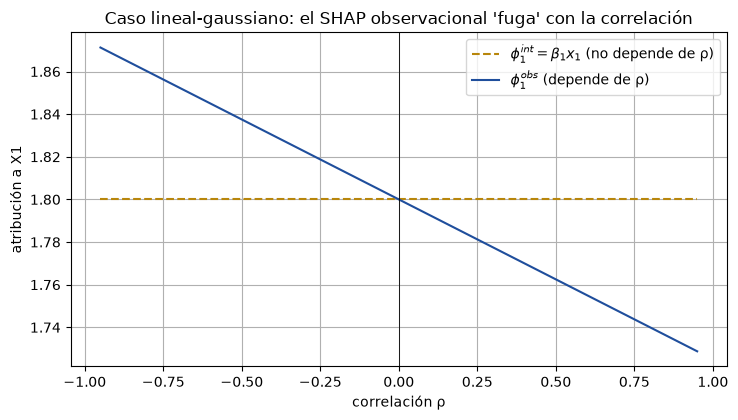

In [5]:
# Figura · la fuga del SHAP observacional crece con la correlación
rhos = np.linspace(-0.95, 0.95, 25)
fuga = [0.5*r*(b2g*(s2/s1)*xq[0] - b1g*(s1/s2)*xq[1]) for r in rhos]
plt.figure(figsize=(7.5, 4.3))
plt.plot(rhos, [b1g*xq[0]]*len(rhos), "--", color="#b8860b", label=r"$\phi^{int}_1=\beta_1 x_1$ (no depende de ρ)")
plt.plot(rhos, [b1g*xq[0] + fr for fr in fuga], "-", color="#1f4e9c", label=r"$\phi^{obs}_1$ (depende de ρ)")
plt.axvline(0, color="k", lw=.6)
plt.xlabel("correlación ρ"); plt.ylabel("atribución a X1")
plt.title("Caso lineal-gaussiano: el SHAP observacional 'fuga' con la correlación")
plt.legend(); plt.tight_layout(); plt.show()

## Sección 3 · Cuando los ausentes son descendientes: el SCM y la atribución causal

La fórmula intervencional de la Definición 2.2 supuso que las ausentes **no son descendientes** de las intervenidas (por eso se integraba contra la marginal). Si $X_S$ tiene descendientes entre las ausentes, intervenir $X_S$ **propaga** el cambio a esos descendientes a través de sus *ecuaciones estructurales*. Para tenerlo en cuenta hace falta el grafo causal.

> **Definición 3.1 (modelo causal estructural, SCM).** Un SCM es un conjunto de ecuaciones $V_i:=g_i(\mathrm{pa}(V_i),U_i)$ que generan cada variable a partir de sus **padres causales** $\mathrm{pa}(V_i)$ y un ruido $U_i$. Intervenir $do(X_S=x_S)$ reemplaza las ecuaciones de $X_S$ por las constantes $x_S$; al **simular** el sistema, los descendientes de $X_S$ cambian en consecuencia.
>
> **Definición 3.2 (valor causal).** $v_{\mathrm{caus}}(S)=\mathbb{E}[f(X)\mid do(X_S=x_S)]$ calculado con el SCM: se fija $X_S=x_S$, se **propaga** a sus descendientes por las ecuaciones estructurales, y las no descendientes se toman de su distribución previa.

**Un SCM con verdad conocida.** Tomemos $X_1\to X_2$ (mediador) y ambas $\to y$:
$$ X_1\sim\mathcal N(0,1),\quad X_2:=\beta_{21}X_1+\varepsilon,\quad y\sim\mathrm{Bernoulli}\big(\sigma(\beta_1 X_1+\beta_2 X_2)\big). $$
Elegimos los coeficientes para que el efecto de $X_1$ sobre $y$ sea **mayormente indirecto** (vía $X_2$). Entrenamos $f$ sobre $(X_1,X_2)$ y calculamos la **importancia media** $\frac1n\sum|\phi_i|$ con las **tres** funciones de valor. Cada una muestrea las ausentes de modo distinto:

- **observacional:** condiciona ($X_2\mid X_1$ y $X_1\mid X_2$);
- **marginal/intervencional:** muestrea independiente (rompe $X_1\to X_2$);
- **causal:** intervenir $X_1$ propaga a $X_2$; intervenir $X_2$ no altera a $X_1$ (es aguas abajo).

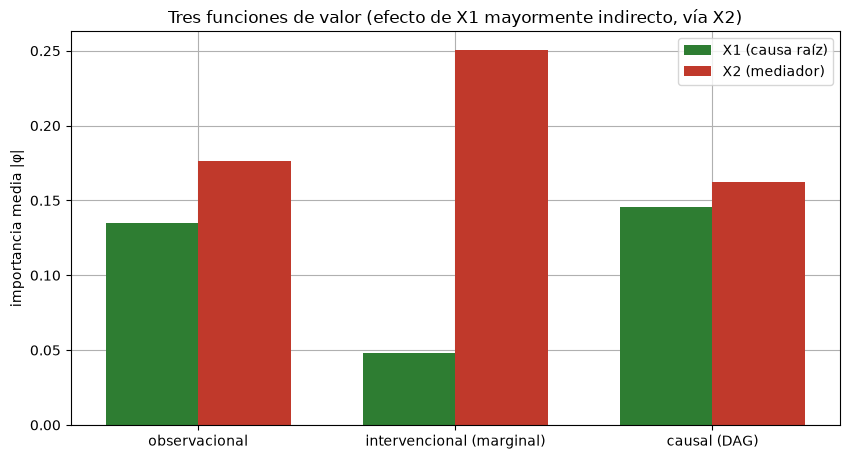

observacional                 |phi(X1)|=0.135   |phi(X2)|=0.176
intervencional (marginal)     |phi(X1)|=0.048   |phi(X2)|=0.250
causal (DAG)                  |phi(X1)|=0.145   |phi(X2)|=0.163


In [6]:
def atribuciones_scm(b21=1.0, b1=0.3, b2=1.5, n=4000, n_q=200, qi=0, seed=0):
    # SCM X1->X2->y, X1->y. Importancia |phi| promedio (n_q casos), atribución del
    # caso qi y valores de coalición (causal) de ese caso.
    rl = np.random.default_rng(seed)
    X1 = rl.normal(0, 1, n)
    X2 = b21 * X1 + rl.normal(0, 0.5, n)
    yb = (rl.uniform(size=n) < 1 / (1 + np.exp(-(b1 * X1 + b2 * X2)))).astype(int)
    D = pd.DataFrame({"X1": X1, "X2": X2})
    m = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                      eval_metric="logloss", random_state=RANDOM_STATE).fit(D, yb)
    f = lambda B: m.predict_proba(B)[:, 1]
    bg = D.sample(600, random_state=RANDOM_STATE).reset_index(drop=True)
    sl12 = np.cov(X1, X2)[0, 1] / np.var(X2)
    sd1g2 = np.std(X1 - sl12 * X2); sd2g1 = np.std(X2 - b21 * X1)

    def v(kind, S, xq):
        B = bg.copy()
        if kind == "marg":
            if "X1" in S: B["X1"] = xq["X1"]
            if "X2" in S: B["X2"] = xq["X2"]
        elif kind == "caus":
            if "X1" in S:
                B["X1"] = xq["X1"]
                if "X2" not in S:
                    B["X2"] = b21 * xq["X1"] + rl.normal(0, sd2g1, len(B))
            if "X2" in S: B["X2"] = xq["X2"]
        else:
            if set(S) == {"X1"}:
                B["X1"] = xq["X1"]; B["X2"] = b21 * xq["X1"] + rl.normal(0, sd2g1, len(B))
            elif set(S) == {"X2"}:
                B["X2"] = xq["X2"]; B["X1"] = sl12 * xq["X2"] + rl.normal(0, sd1g2, len(B))
            elif set(S) == {"X1", "X2"}:
                B["X1"] = xq["X1"]; B["X2"] = xq["X2"]
        return f(B).mean()

    def phivals(kind, xq):
        ve = v(kind, [], xq); v1 = v(kind, ["X1"], xq)
        v2 = v(kind, ["X2"], xq); v12 = v(kind, ["X1", "X2"], xq)
        return (0.5*((v1-ve)+(v12-v2)), 0.5*((v2-ve)+(v12-v1))), {"e": ve, "1": v1, "2": v2, "12": v12}

    imp = {}; attr = {}; vals = {}
    for kind in ["obs", "marg", "caus"]:
        P = np.array([phivals(kind, D.iloc[t])[0] for t in range(n_q)])
        imp[kind] = np.abs(P).mean(0)
        attr[kind], vals[kind] = phivals(kind, D.iloc[qi])
    return {"imp": imp, "attr": attr, "vals": vals}

res = atribuciones_scm()
metodos = [("observacional", "obs"), ("intervencional (marginal)", "marg"), ("causal (DAG)", "caus")]
i1 = [res["imp"][k][0] for _, k in metodos]; i2 = [res["imp"][k][1] for _, k in metodos]
xpos = np.arange(3); w = 0.36
plt.figure(figsize=(8.6, 4.7))
plt.bar(xpos - w/2, i1, w, color="#2e7d32", label="X1 (causa raíz)")
plt.bar(xpos + w/2, i2, w, color="#c0392b", label="X2 (mediador)")
plt.xticks(xpos, [n for n, _ in metodos]); plt.ylabel("importancia media |φ|")
plt.title("Tres funciones de valor (efecto de X1 mayormente indirecto, vía X2)")
plt.legend(); plt.tight_layout(); plt.show()
for n, k in metodos:
    print(f"{n:28s}  |phi(X1)|={res['imp'][k][0]:.3f}   |phi(X2)|={res['imp'][k][1]:.3f}")

**Lectura.** Las tres difieren para el *mismo* modelo. La **marginal** rompe la cadena $X_1\to X_2$ y subestima a $X_1$ (su efecto indirecto se le adjudica al mediador $X_2$); la **causal** reconoce la propagación y restituye la importancia de $X_1$; la **observacional** queda en medio, mezclando por correlación. Como en la Proposición 2.1, **los datos no bastan** para decidir cuál es correcta: la respuesta es una afirmación causal que requiere el grafo.

## Sección 4 · El efecto en un modelo real (German Credit)

La misma distinción se traslada al modelo entrenado sobre datos reales. Calculamos las importancias globales $\frac1n\sum|\phi_i|$ con SHAP **observacional** (`tree_path_dependent`) e **intervencional** (`interventional`) y contrastamos.

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


AUC (XGBoost): 0.769


C:\Users\cizai\AppData\Local\Temp\ipykernel_61416\4149782999.py:16: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  top = imp.loc[imp.max(1).sort_values(ascending=False).index[:10]][::-1]


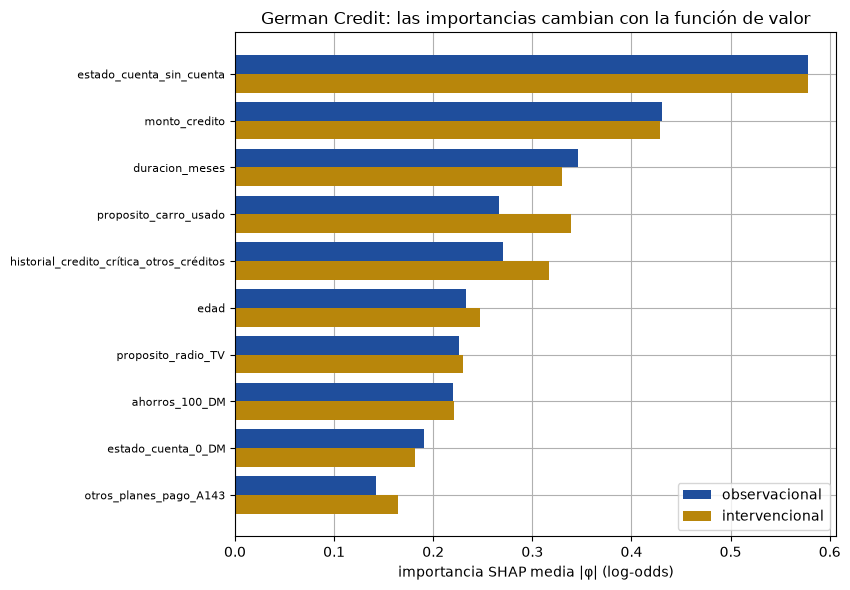

Mayores discrepancias observacional vs intervencional:
proposito_carro_usado                       0.0722
historial_credito_crítica_otros_créditos    0.0462
ahorros_1000_DM                             0.0303
otros_planes_pago_A143                      0.0224
duracion_meses                              0.0163


In [7]:
df = load_german_credit()
y = df["riesgo_bueno"]
X = pd.get_dummies(df.drop(columns=["riesgo", "riesgo_bueno", "estado_personal_sexo"]),
                   drop_first=True).astype(float)
X.columns = [re.sub(r"_+", "_", re.sub(r"[^0-9A-Za-zÀ-ſ_]", "_", c)).strip("_") for c in X.columns]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
clf = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.9,
                    eval_metric="logloss", random_state=RANDOM_STATE).fit(X_tr, y_tr)
print(f"AUC (XGBoost): {roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]):.3f}")

sv_obs = shap.TreeExplainer(clf, feature_perturbation="tree_path_dependent")(X_te)
fondo = X_tr.sample(200, random_state=RANDOM_STATE)
sv_int = shap.TreeExplainer(clf, data=fondo, feature_perturbation="interventional")(X_te)
imp = pd.DataFrame({"observacional": np.abs(sv_obs.values).mean(0),
                    "intervencional": np.abs(sv_int.values).mean(0)}, index=X.columns)
top = imp.loc[imp.max(1).sort_values(ascending=False).index[:10]][::-1]
ypos = np.arange(len(top)); h = 0.4
plt.figure(figsize=(8.6, 6))
plt.barh(ypos + h/2, top["observacional"], h, color="#1f4e9c", label="observacional")
plt.barh(ypos - h/2, top["intervencional"], h, color="#b8860b", label="intervencional")
plt.yticks(ypos, top.index, fontsize=8); plt.xlabel("importancia SHAP media |φ| (log-odds)")
plt.title("German Credit: las importancias cambian con la función de valor")
plt.legend(); plt.tight_layout(); plt.show()
dif = (imp["observacional"] - imp["intervencional"]).abs().sort_values(ascending=False)
print("Mayores discrepancias observacional vs intervencional:")
print(dif.head(5).round(4).to_string())

Las diferencias son reales: variables correlacionadas con otras informativas ganan o pierden importancia al cambiar la función de valor. Y, como en la teoría, **el dato de entrenamiento no dice cuál es la lectura causal**: para eso hace falta saber qué variable es causa, mediador o *proxy*.

## Sección 5 · Causal SHAP, Shapley asimétrico y do-SHAP

Tres líneas de trabajo incorporan estructura causal a la atribución:

- **Causal SHAP** (Heskes, Sijben, Bucur & Claassen, 2020) redefine $v(S)$ con intervenciones que respetan un grafo causal **parcial**, propagando a los descendientes —la versión "causal" de la Sección 3—. Distingue, además, la contribución **directa** de la **indirecta** (a través de descendientes).
- **Shapley asimétrico** (Frye, Rowat & Feige, 2020) restringe el promedio a las permutaciones **compatibles con un orden causal** conocido. Si $X_1$ es ancestro de $X_2$, solo cuentan los órdenes con $X_1$ antes que $X_2$, concentrando el crédito en la causa (lo ilustramos en el Ejemplo complementario 5).
- **do-SHAP / interventional SHAP** (Janzing, Minorics & Blöbaum, 2020; Parafita et al., 2025) usa la versión marginal como estimador de $\mathbb{E}[f\mid do(\cdot)]$: exacta cuando las variables intervenidas son **raíces**, aproximada en otro caso.

> **Observación 5.1 (la moraleja del capítulo).** Las tres requieren, como insumo, el **grafo causal** (o al menos un orden parcial). La explicabilidad, por sí sola, no lo descubre a partir de los datos —la Proposición 2.1 lo deja claro: con los mismos datos, distintas hipótesis causales producen atribuciones distintas, todas igualmente "fieles al modelo"—. Para atribuir *causalmente*, y más aún para responder "¿qué pasaría si interviniéramos?", se necesita el aparato de la **inferencia causal**: resultados potenciales, DAGs y estimación de efectos. Esa es la Sección 2 del curso, a partir del cuaderno 05.

## Síntesis

- El valor de Shapley reparte $f(x)$ con la **única** regla que cumple eficiencia, simetría, nulidad y linealidad; su fórmula es un promedio de contribuciones marginales sobre todos los órdenes de llegada.
- Todo depende de la **función de valor** $v(S)$: la **observacional** integra contra la condicional (conserva la correlación) y la **intervencional** contra la marginal (la rompe, vía el operador $do$).
- La **Proposición 2.1** lo demuestra en el caso lineal-gaussiano: $\phi^{\mathrm{int}}_i=\beta_i x_i$ exacto; $\phi^{\mathrm{obs}}_i$ añade una fuga proporcional a $\rho$. Verificado numéricamente.
- Con **descendientes**, ni siquiera la marginal basta: hace falta el SCM (atribución causal), como mostró el experimento con verdad conocida.
- En datos reales, las dos lecturas difieren y **los datos no eligen**: se necesita el modelo causal → cuaderno 05.

## Ejemplos complementarios

Cinco ejemplos desarrollados que extienden la teoría y la llevan al modelo real.

### Ejemplo 1 · Cuanto más fuerte la mediación, más divergen las atribuciones

Se varía $\beta_{21}$ (fuerza de $X_1\to X_2$) y se observa la importancia atribuida a $X_1$ por cada función de valor: a mayor mediación, la lectura causal reconoce más a $X_1$ y la marginal menos.

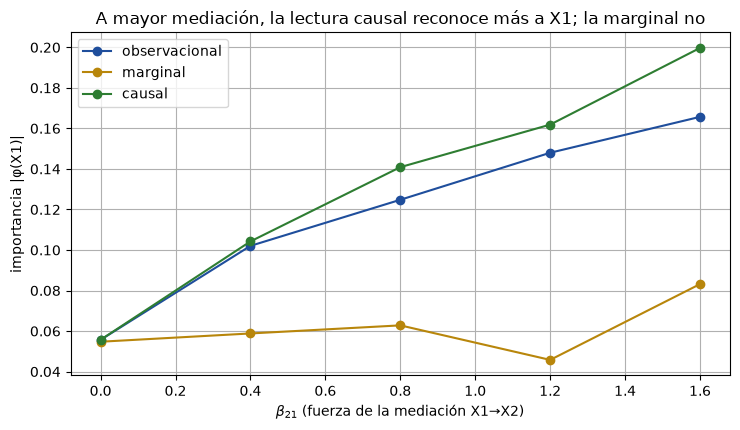

In [8]:
b21s = [0.0, 0.4, 0.8, 1.2, 1.6]
curvas = {"obs": [], "marg": [], "caus": []}
for b in b21s:
    aa = atribuciones_scm(b21=b, n_q=80)
    for k in curvas:
        curvas[k].append(aa["imp"][k][0])
plt.figure(figsize=(7.5, 4.4))
est = {"obs": ("observacional", "#1f4e9c"), "marg": ("marginal", "#b8860b"), "caus": ("causal", "#2e7d32")}
for k, (lab, c) in est.items():
    plt.plot(b21s, curvas[k], "-o", color=c, label=lab)
plt.xlabel(r"$\beta_{21}$ (fuerza de la mediación X1→X2)"); plt.ylabel("importancia |φ(X1)|")
plt.title("A mayor mediación, la lectura causal reconoce más a X1; la marginal no")
plt.legend(); plt.tight_layout(); plt.show()

### Ejemplo 2 · La discrepancia depende del caso explicado

La brecha entre la atribución observacional y la causal de $X_2$ no es constante: depende del punto $x_q$.

In [9]:
print(f"{'caso':>5} | {'phi_obs(X2)':>11} | {'phi_caus(X2)':>12} | {'brecha':>7}")
for qi in range(6):
    aa = atribuciones_scm(qi=qi)
    o, c = aa["attr"]["obs"][1], aa["attr"]["caus"][1]
    print(f"{qi:5d} | {o:+11.3f} | {c:+12.3f} | {abs(o - c):7.3f}")

 caso | phi_obs(X2) | phi_caus(X2) |  brecha


    0 |      +0.164 |       +0.146 |   0.018


    1 |      -0.035 |       -0.059 |   0.024


    2 |      +0.121 |       +0.105 |   0.016


    3 |      +0.174 |       +0.153 |   0.020


    4 |      +0.175 |       +0.155 |   0.019


    5 |      -0.107 |       -0.133 |   0.026


### Ejemplo 3 · Observacional vs intervencional en una variable real

Se aísla, para `duracion_meses`, la importancia bajo ambas funciones de valor en el modelo de German Credit.

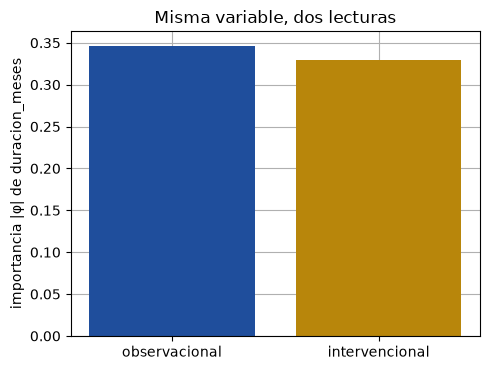

duracion_meses: observacional=0.3464  intervencional=0.3300  ratio=1.05


In [10]:
j = list(X.columns).index("duracion_meses")
io = np.abs(sv_obs.values[:, j]).mean(); ii = np.abs(sv_int.values[:, j]).mean()
plt.figure(figsize=(5, 3.8))
plt.bar(["observacional", "intervencional"], [io, ii], color=["#1f4e9c", "#b8860b"])
plt.ylabel("importancia |φ| de duracion_meses"); plt.title("Misma variable, dos lecturas")
plt.tight_layout(); plt.show()
print(f"duracion_meses: observacional={io:.4f}  intervencional={ii:.4f}  ratio={io/ii:.2f}")

### Ejemplo 4 · Estabilidad de la estimación intervencional según el fondo

La versión intervencional estima una esperanza sobre un **fondo**. Se mide cómo varía la importancia de una variable con el tamaño del fondo.

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


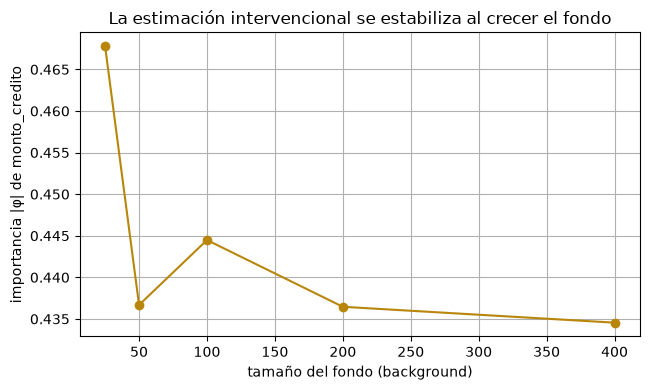

importancia por tamaño de fondo: [np.float64(0.4678), np.float64(0.4367), np.float64(0.4445), np.float64(0.4365), np.float64(0.4346)]


In [11]:
jj = list(X.columns).index("monto_credito")
tam = [25, 50, 100, 200, 400]; vals_t = []
for t in tam:
    fb = X_tr.sample(t, random_state=RANDOM_STATE)
    sv = shap.TreeExplainer(clf, data=fb, feature_perturbation="interventional")(X_te.iloc[:120])
    vals_t.append(np.abs(sv.values[:, jj]).mean())
plt.figure(figsize=(6.6, 4))
plt.plot(tam, vals_t, "-o", color="#b8860b")
plt.xlabel("tamaño del fondo (background)"); plt.ylabel("importancia |φ| de monto_credito")
plt.title("La estimación intervencional se estabiliza al crecer el fondo")
plt.tight_layout(); plt.show()
print("importancia por tamaño de fondo:", [round(v, 4) for v in vals_t])

### Ejemplo 5 · Shapley simétrico frente a Shapley asimétrico

Con el orden causal $X_1\to X_2$, el Shapley **asimétrico** promedia solo el orden compatible ($X_1$ antes que $X_2$), concentrando el crédito en la causa. Se compara con el simétrico usando la función de valor causal del SCM.

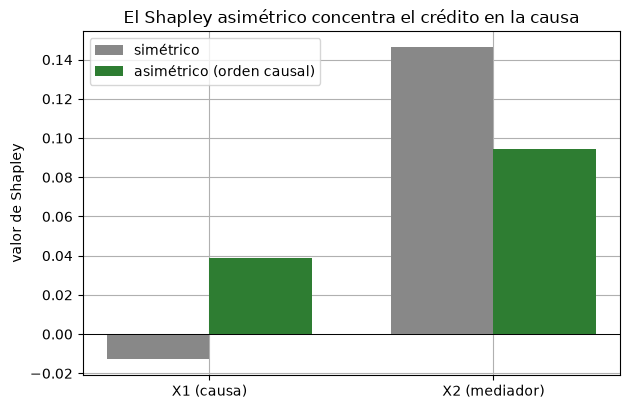

simétrico : X1=-0.013  X2=+0.146
asimétrico: X1=+0.039  X2=+0.095


In [12]:
vals = atribuciones_scm()["vals"]["caus"]
ve, v1, v2, v12 = vals["e"], vals["1"], vals["2"], vals["12"]
phi1_sim = 0.5*((v1-ve)+(v12-v2)); phi2_sim = 0.5*((v2-ve)+(v12-v1))    # simétrico (ambos órdenes)
phi1_asim = v1 - ve; phi2_asim = v12 - v1                                # asimétrico (orden X1->X2)
xpos = np.arange(2); w = 0.36
plt.figure(figsize=(6.4, 4.2))
plt.bar(xpos - w/2, [phi1_sim, phi2_sim], w, color="#888", label="simétrico")
plt.bar(xpos + w/2, [phi1_asim, phi2_asim], w, color="#2e7d32", label="asimétrico (orden causal)")
plt.xticks(xpos, ["X1 (causa)", "X2 (mediador)"]); plt.axhline(0, color="k", lw=.7)
plt.ylabel("valor de Shapley"); plt.title("El Shapley asimétrico concentra el crédito en la causa")
plt.legend(); plt.tight_layout(); plt.show()
print(f"simétrico : X1={phi1_sim:+.3f}  X2={phi2_sim:+.3f}")
print(f"asimétrico: X1={phi1_asim:+.3f}  X2={phi2_asim:+.3f}")

## Referencias (APA 7)

- Frye, C., Rowat, C., & Feige, I. (2020). Asymmetric Shapley values: Incorporating causal knowledge into model-agnostic explainability. *NeurIPS 33*, 1229–1239.
- Heskes, T., Sijben, E., Bucur, I. G., & Claassen, T. (2020). Causal Shapley values: Exploiting causal knowledge to explain individual predictions of complex models. *NeurIPS 33*, 4778–4789.
- Janzing, D., Minorics, L., & Blöbaum, P. (2020). Feature relevance quantification in explainable AI: A causal problem. *AISTATS*, 2907–2916.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*.
- Parafita, Á., Garriga, T., Brando, A., & Cazorla, F. J. (2025). *Practical do-Shapley explanations with estimand-agnostic causal inference* [Preprint]. arXiv:2509.20211.
- Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2nd ed.). Cambridge University Press.
- Shapley, L. S. (1953). A value for n-person games. In *Contributions to the Theory of Games II* (pp. 307–317). Princeton University Press.
- Sundararajan, M., & Najmi, A. (2020). The many Shapley values for model explanation. *ICML*, 9269–9278.